In [1]:
import rasterio
import numpy as np
import json
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
from PIL import Image
from shapely import geometry
from pyproj import Transformer

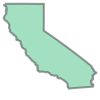

In [2]:
state_boundary_file_path = r"C:\Users\Kristof\Downloads\us-state-boundaries.json"

with open(state_boundary_file_path) as file:
    data = json.load(file)
CA = data[0]['st_asgeojson']['geometry']['coordinates'][0][0]
CA = geometry.Polygon(CA)
CA

In [3]:
data_dict = {"FUEL": r"US_140_FBFM13\us_140fbfm13.tif",
            r"TOPOGRAPHY\ASPECT": r"LF2020_Asp_220_CONUS\LC20_Asp_220.tif",
            r"TOPOGRAPHY\ELEVATION": r"LF2020_Elev_220_CONUS\LC20_Elev_220.tif",
            r"TOPOGRAPHY\SLOPE": r"LF2020_SlpD_220_CONUS\LC20_SlpD_220.tif"}

coord_dict = {1: {"top": 37.5, "bottom": 32, "left": -119.5, "right": -114},
             2: {"top": 37.5, "bottom": 32, "left": -125, "right": -119.5},
             3: {"top": 43, "bottom": 37.5, "left": -125, "right": -119.5},
             4: {"top": 43, "bottom": 37.5, "left": -119.5, "right": -114}}

In [4]:
variable = "FUEL"
j = 4
path = f"D:\Thesis\data\{variable}\{j}\{data_dict[variable]}"
path

'D:\\Thesis\\data\\FUEL\\4\\US_140_FBFM13\\us_140fbfm13.tif'

In [5]:
dataset = rasterio.open(path)

dst_crs = '+proj=latlon'

with rasterio.open(path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height})
    new_path = f'D:\Thesis\data\{variable}\{j}\latlon_resampled.tif'
    with rasterio.open(new_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)
            
dataset = rasterio.open(new_path)

top_y, left_x = dataset.index(coord_dict[j]["left"], coord_dict[j]["top"])
bottom_y, right_x = dataset.index(coord_dict[j]["right"], coord_dict[j]["bottom"])

# Image.fromarray(dataset.read(1)[top_y:bottom_y, left_x:right_x]).show()

data_array = dataset.read(1)[top_y:bottom_y, left_x:right_x]

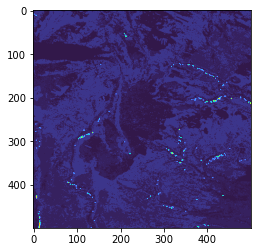

In [6]:
to_illustrate = data_array[:500, :500].copy()

to_illustrate[to_illustrate == -32768] = 0

plt.imshow(to_illustrate, cmap="turbo")
plt.show()